# Unstructured model flight track only paired with DC8 Observations

##### This example utilizes an aircraft track only model file to pair with DC8 aircraft observations

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

### MELODIES MONET requires only a few simple commands. 

##### an = driver.analysis()
##### an.read_control()
##### an.open_models()
##### an.open_obs()
##### an.pair_data()
##### an.save_analysis()
##### an.plotting()
##### an.stats()

## Initiate the analysis class

Now lets create an instance of the {mod}`melodies_monet.driver` {class}`~melodies_monet.driver.analysis` class.
It consists of 4 main parts: model instances, observation instances, a paired instance of both.
This will allow us to move things around the plotting function for spatial and overlays and more complex plots.

In [2]:
an = driver.analysis()
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control File

Read in the required yaml control file that sets up all the definitions of what we want to pair and plot.

In [3]:
an.control = './control_1x_track_cesm_se_asia_aq.yaml'
an.read_control()
an.debug = True
an.control_dict

{'analysis': {'start_time': '2024-02-13',
  'end_time': '2024-02-14 23:59:00',
  'output_dir': './output/1x_asia_aq_cesmse',
  'output_dir_save': './output/1x_asia_aq_cesmse',
  'output_dir_read': './output/1x_asia_aq_cesmse',
  'save': {'paired': {'method': 'netcdf',
    'prefix': '0213_jz_asiaaq',
    'data': 'all'}},
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'dc8_cam-chem-se-era5': ['/glade/work/lcthompson/jun_zhang_cs_06122026/output_021324/0213_jz_asiaaq_dc8_cam-chem-se-era5.nc4']}}},
  'download_maps': False,
  'debug': True},
 'model': {'cam-chem-se-era5': {'files': ['/glade/derecho/scratch/lcthompson/thinned_examples/Sample_CESM-SE_track_asiaaq_dc8_2024-02-13.nc'],
   'mod_type': 'cesm_se',
   'is_track': True,
   'scrip_file': '/glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_SCRIP.nc',
   'radius_of_influence': 100000,
   'mapping': {'dc8': {'O3': 'O3', 'NO2': 'NO2', 'T': 'temperature'}},
   'projection': None,
   'plot_kwargs': {'co

## Load the model data 

The driver will automatically loop through the "models" found in the model section of the control file and create model classes for each. Classes include the label, mapping information, and xarray object as well as the filenames.  Note it can open multiple files easily by including wildcards. 

For unstructured models, this will also tell you the grid / scrip file path you are reading. *** NOTE: MPAS and CESM-SE go through the same unstructured CAM reader *** 


#### Pairing can get expensive, so sometimes it is convienient to save the paired output and then do the plotting. If you read directly from the saved netcdf, you DO NOT need to open the observations. You will need to open AT LEAST 1 model file in order to get the 3D extent information required for some plots. 

In [4]:
an.open_models()
an.models
an.models['cam-chem-se-era5'].obj

########### Uncomment if you do want these commands

#an.open_obs() # using a saved netcdf prevents you from needing to open_obs()

#an.pair_data() # using a saved netcdf prevents you from needing to pair_data()

#an.save_analysis() # to use / save output, use the save_analysis()


Scrip file /glade/work/emmons/VRM_Files/ne0np4.GEMS01.ne30x8/grids/GEMS01_ne30x8_np4_SCRIP.nc
['/glade/derecho/scratch/lcthompson/thinned_examples/Sample_CESM-SE_track_asiaaq_dc8_2024-02-13.nc']


In [5]:
# All the info in the model class can be called here.
print(an.models['cam-chem-se-era5'].label)
print(an.models['cam-chem-se-era5'].mapping)

cam-chem-se-era5
{'dc8': {'O3': 'O3', 'NO2': 'NO2', 'T': 'temperature'}}


In [6]:
# here we are opening the saved analysis 
an.read_analysis()

Reading: /glade/work/lcthompson/jun_zhang_cs_06122026/output_021324/0213_jz_asiaaq_dc8_cam-chem-se-era5.nc4


/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
an.control_dict['obs']

{'dc8': {'filename': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/asiaaq_cs_06082026/preprocessing/dc8_data/asiaaq_dc8_merge_all.nc',
  'obs_type': 'aircraft',
  'resample': '60s',
  'variables': {'pressure_obs': {},
   'altitude': {},
   'O3': {'unit_scale': 1, 'unit_scale_method': '*'},
   'NO2': {'unit_scale': 0.001, 'unit_scale_method': '*'}}}}

## Open Obs

Now for monet-analysis we will open preprocessed data in either netcdf icartt or some other format.  We will not be retrieving data like monetio does for some observations (ie aeronet, airnow, etc....).  Instead we will provide utitilies to do this so that users can add more data easily.

Like models we list all obs objects in the yaml file and it will loop through and create driver.observation instances that include the model type, file, objects (i.e. data object) and label  

## Generate plots

Using vertprofile_bins from YAML range: {'start': 10000, 'stop': 110000, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 10000, 'stop': 110000, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 10000, 'stop': 110000, 'step': 5000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 18000, 'step': 1000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 18000, 'step': 1000}
Using vertprofile_bins from YAML range: {'start': 0, 'stop': 18000, 'step': 1000}
Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/1x_asia_aq_cesmse/scatter_dc8.scatter_density.O3.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
Processing scatter density plot for model 'cam-chem-se-era5' and observation 'dc8'...
Saving scatter density plot to ./output/1x_asia_aq_cesmse/scatter_dc8.scatter_density.O3.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


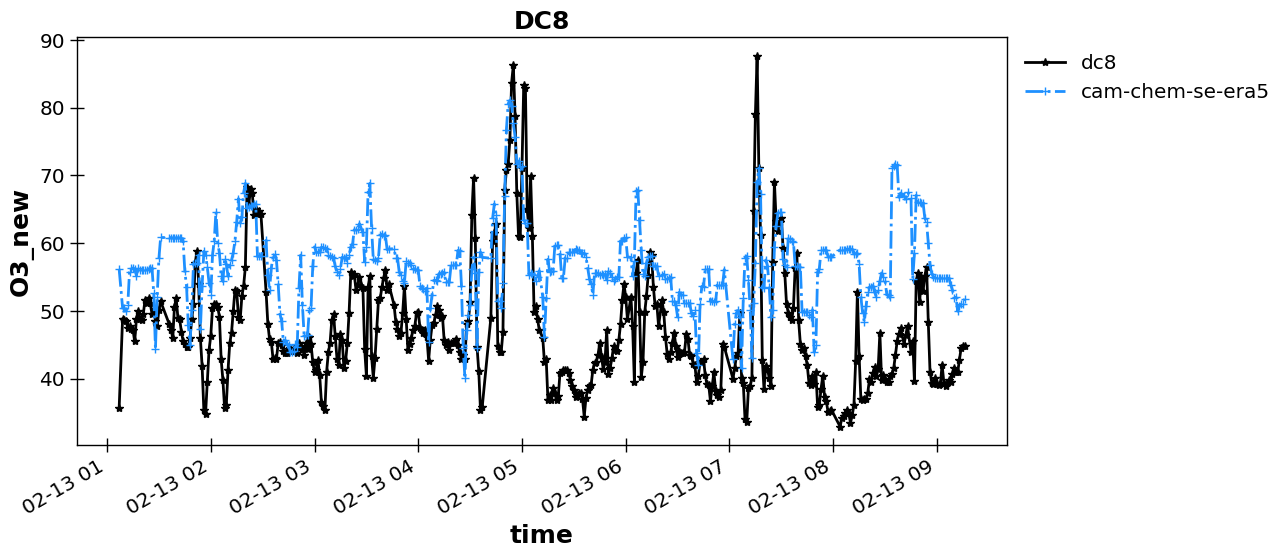

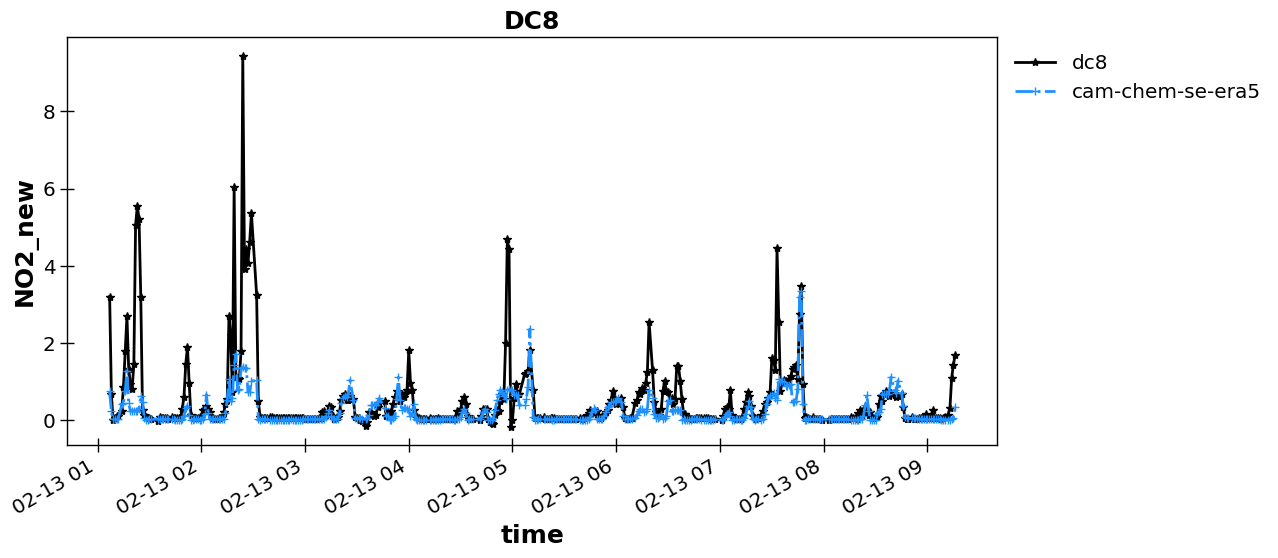

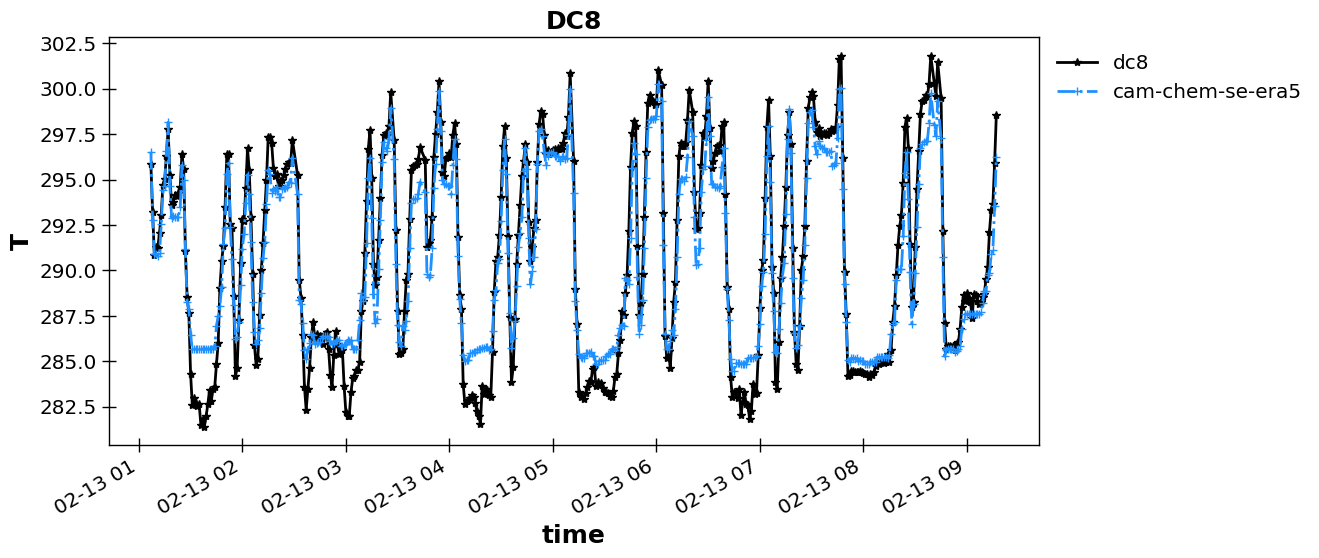

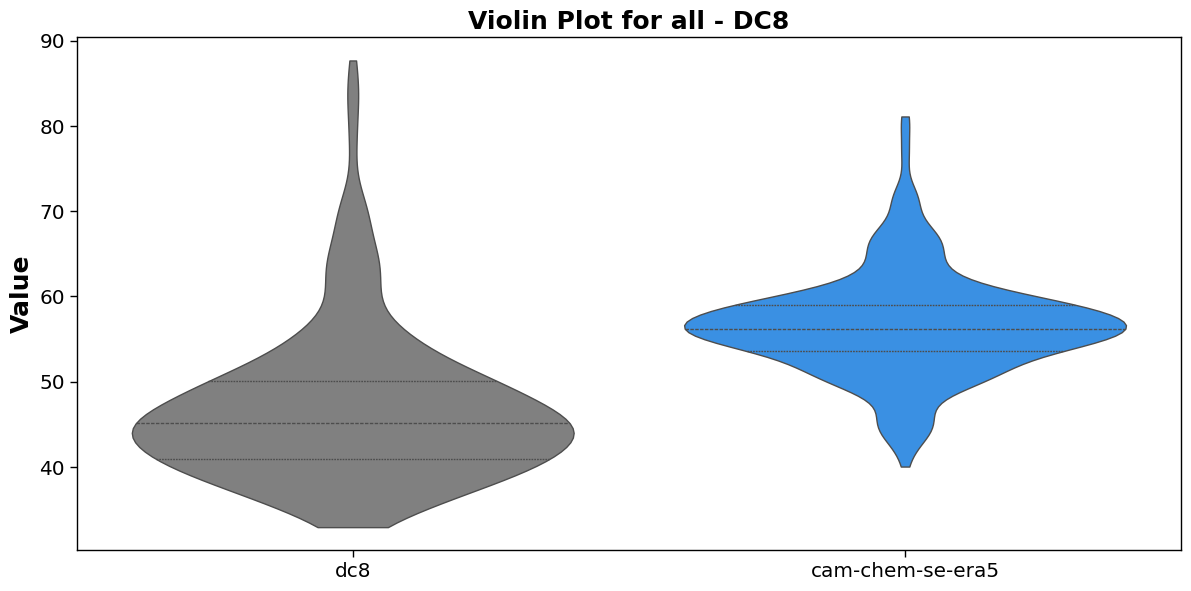

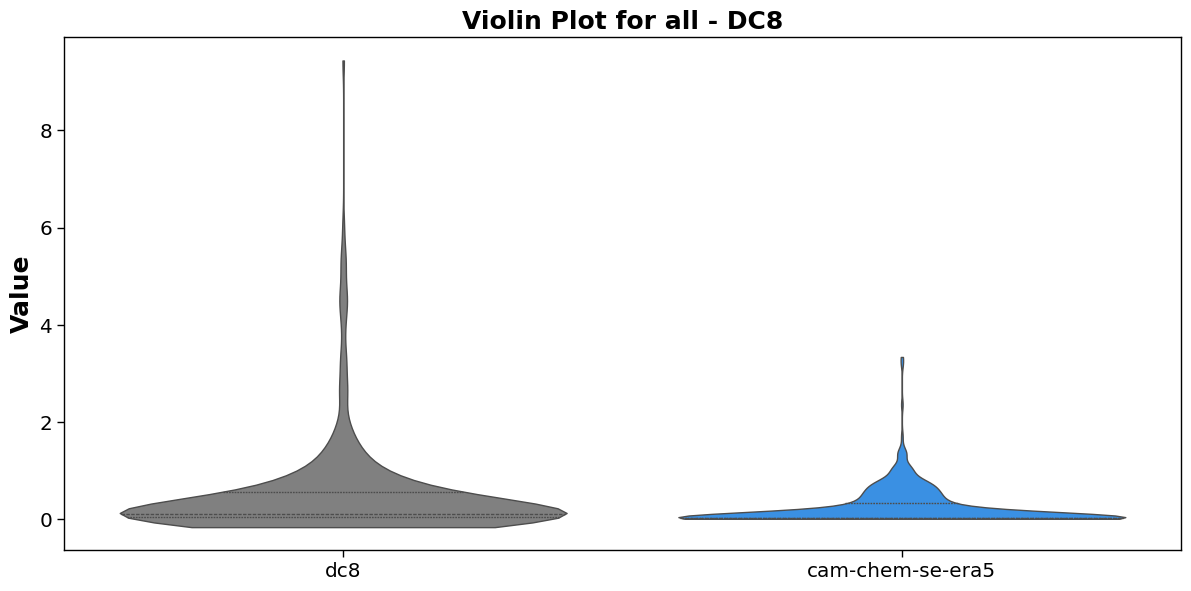

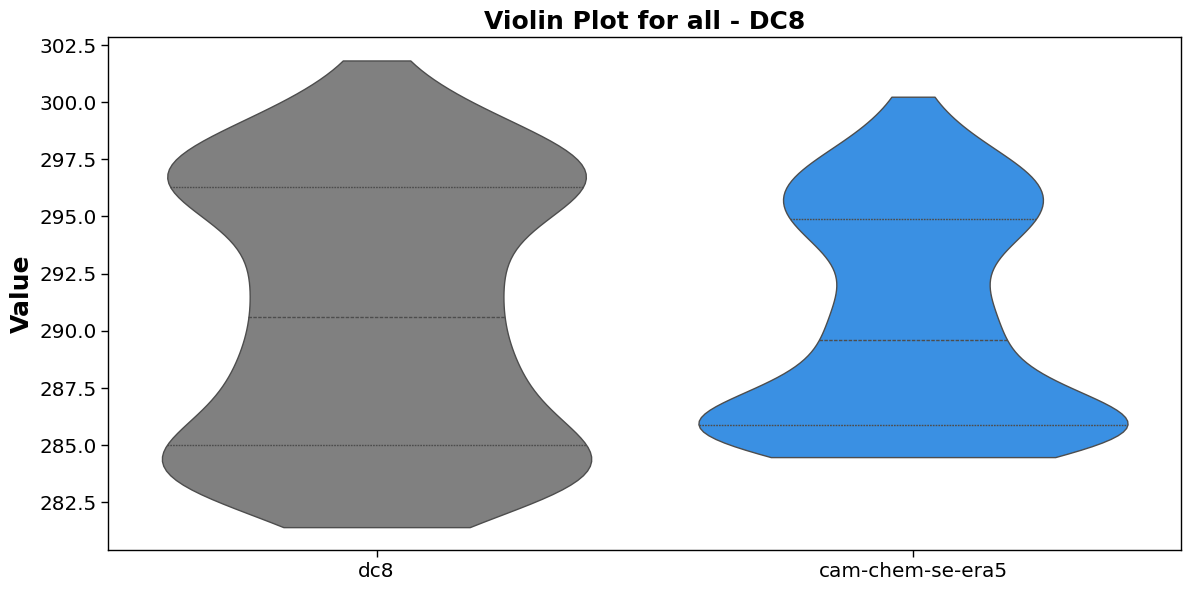

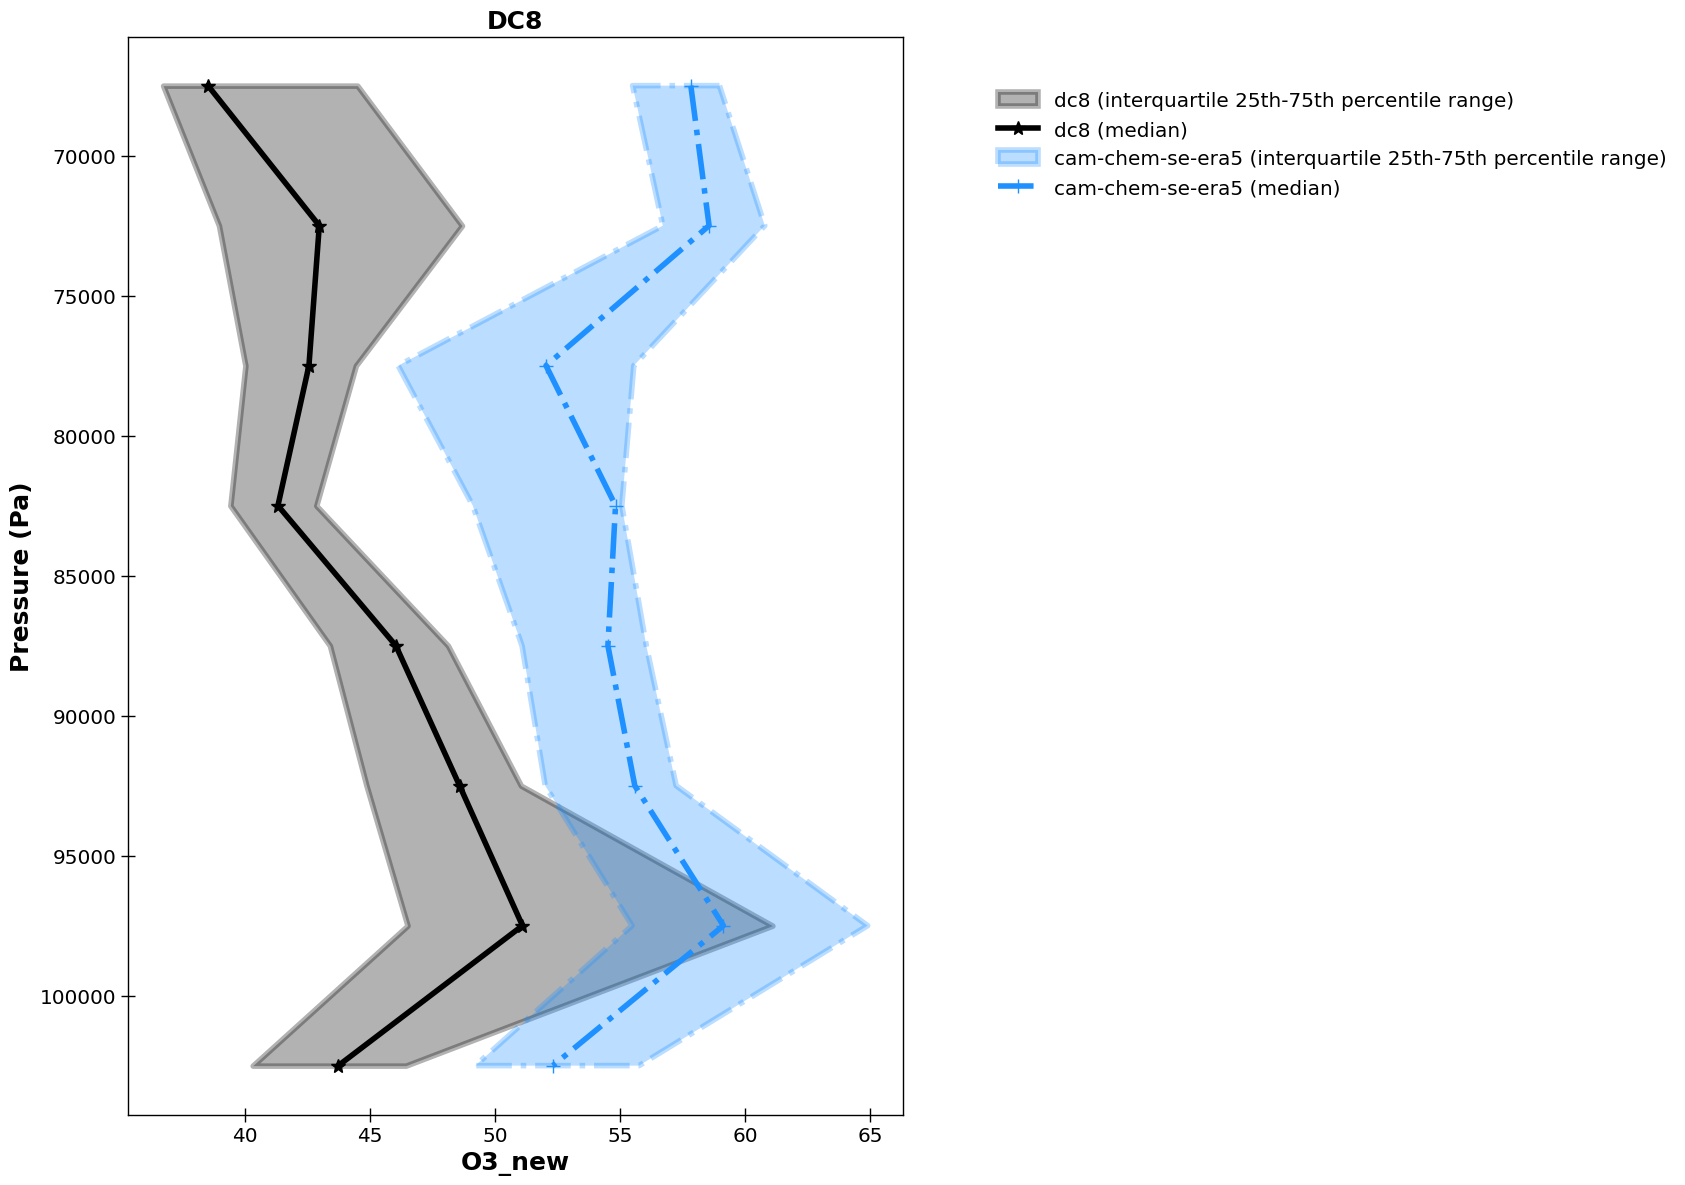

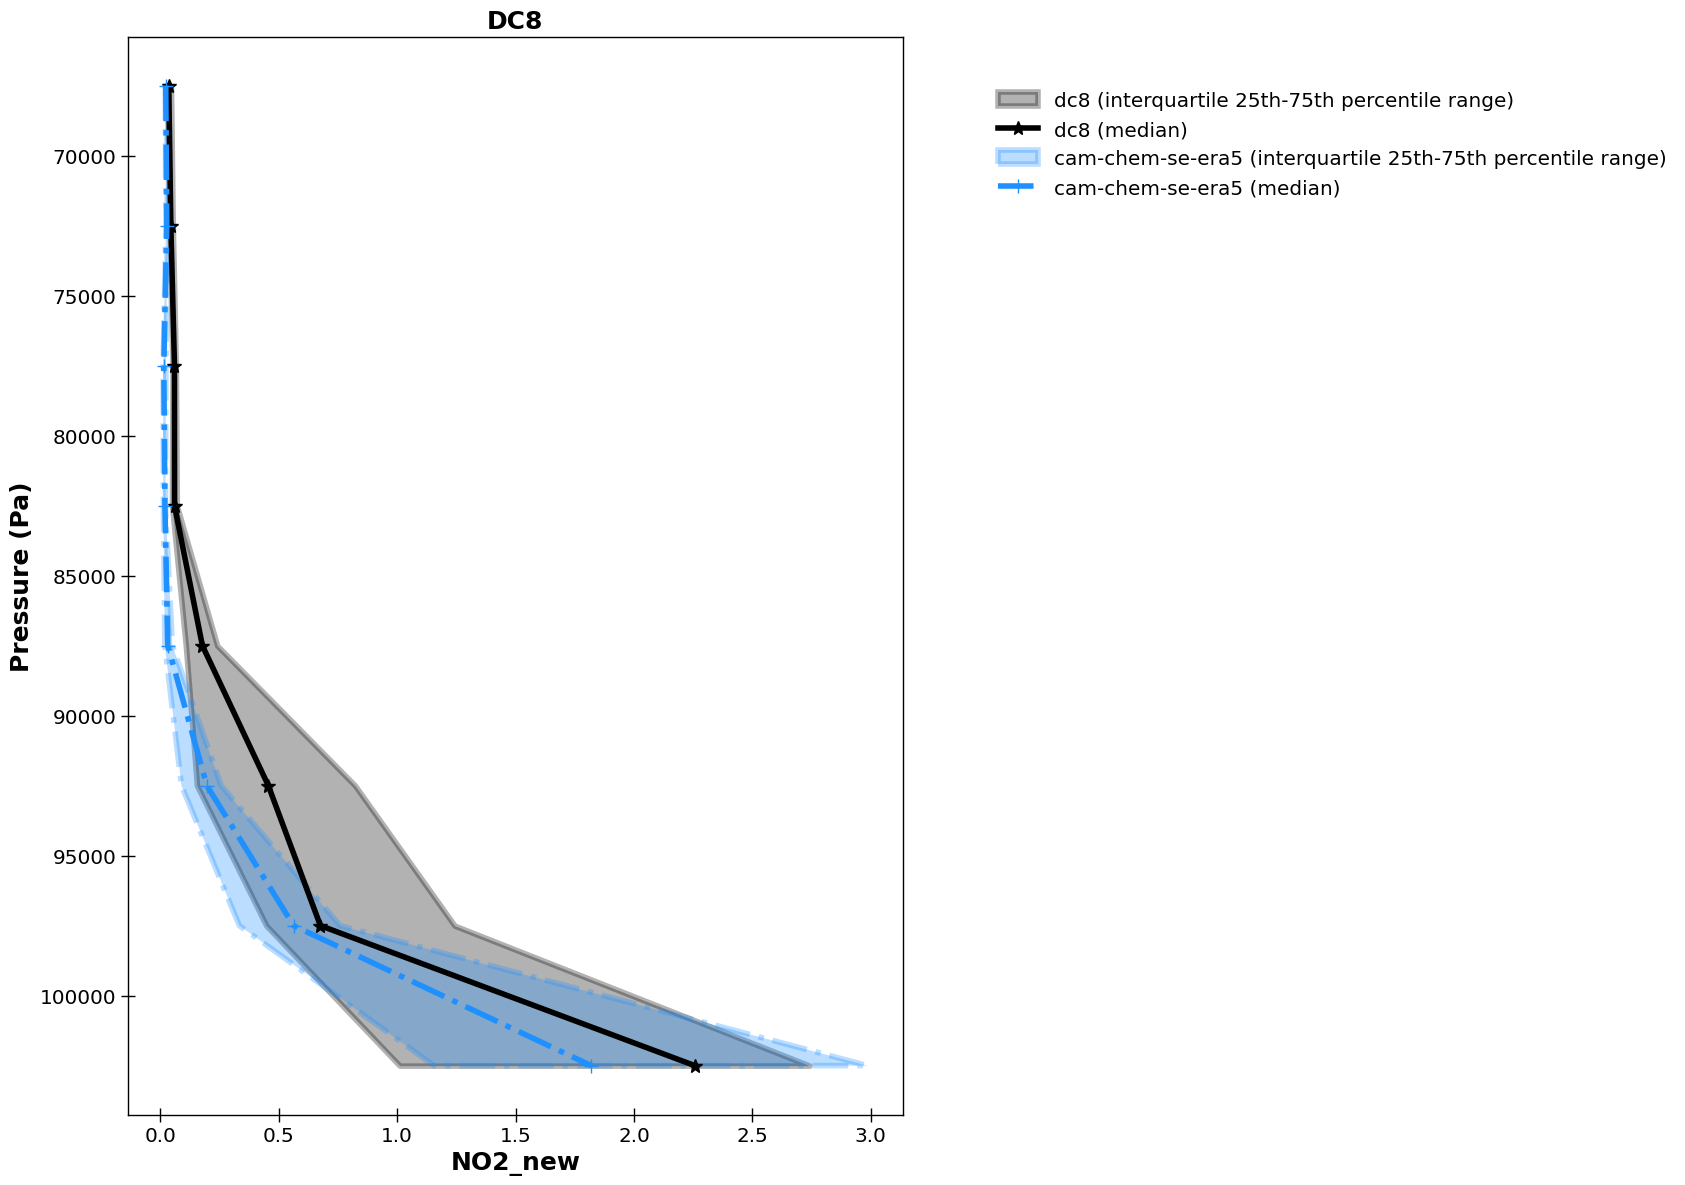

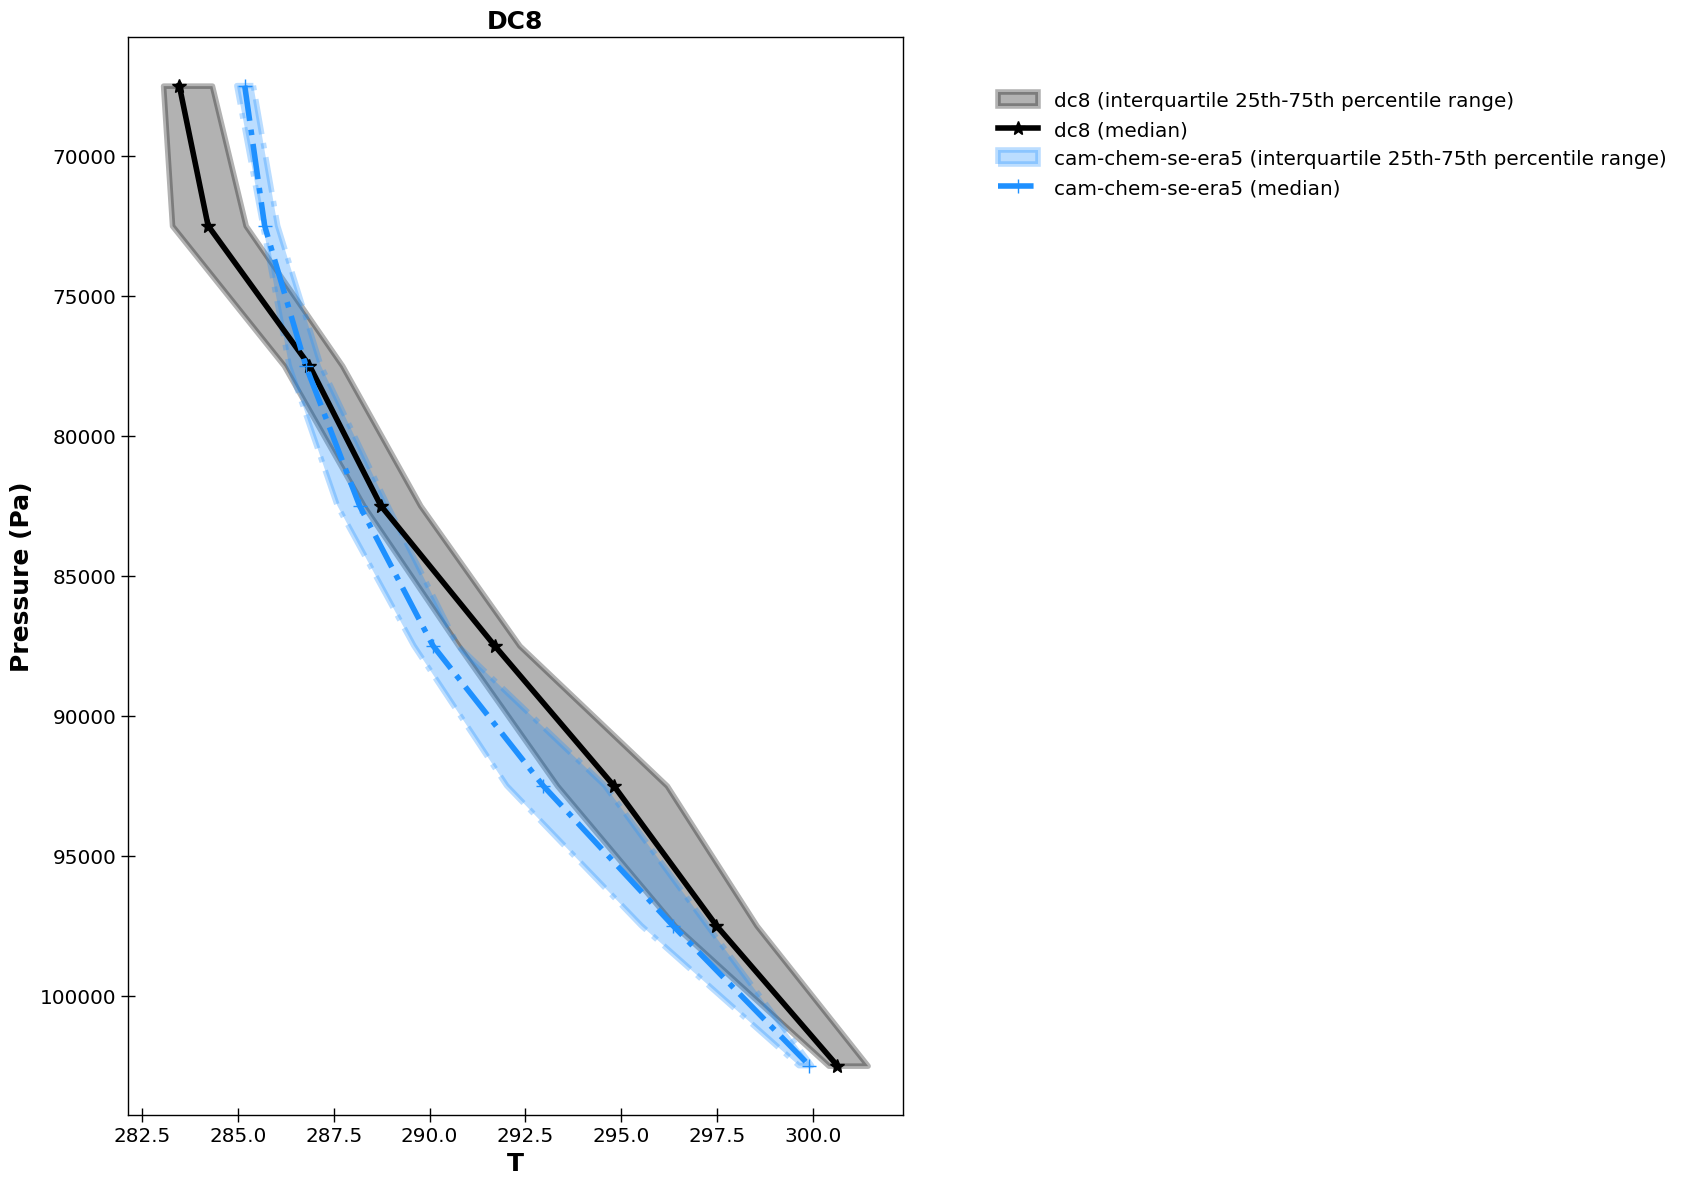

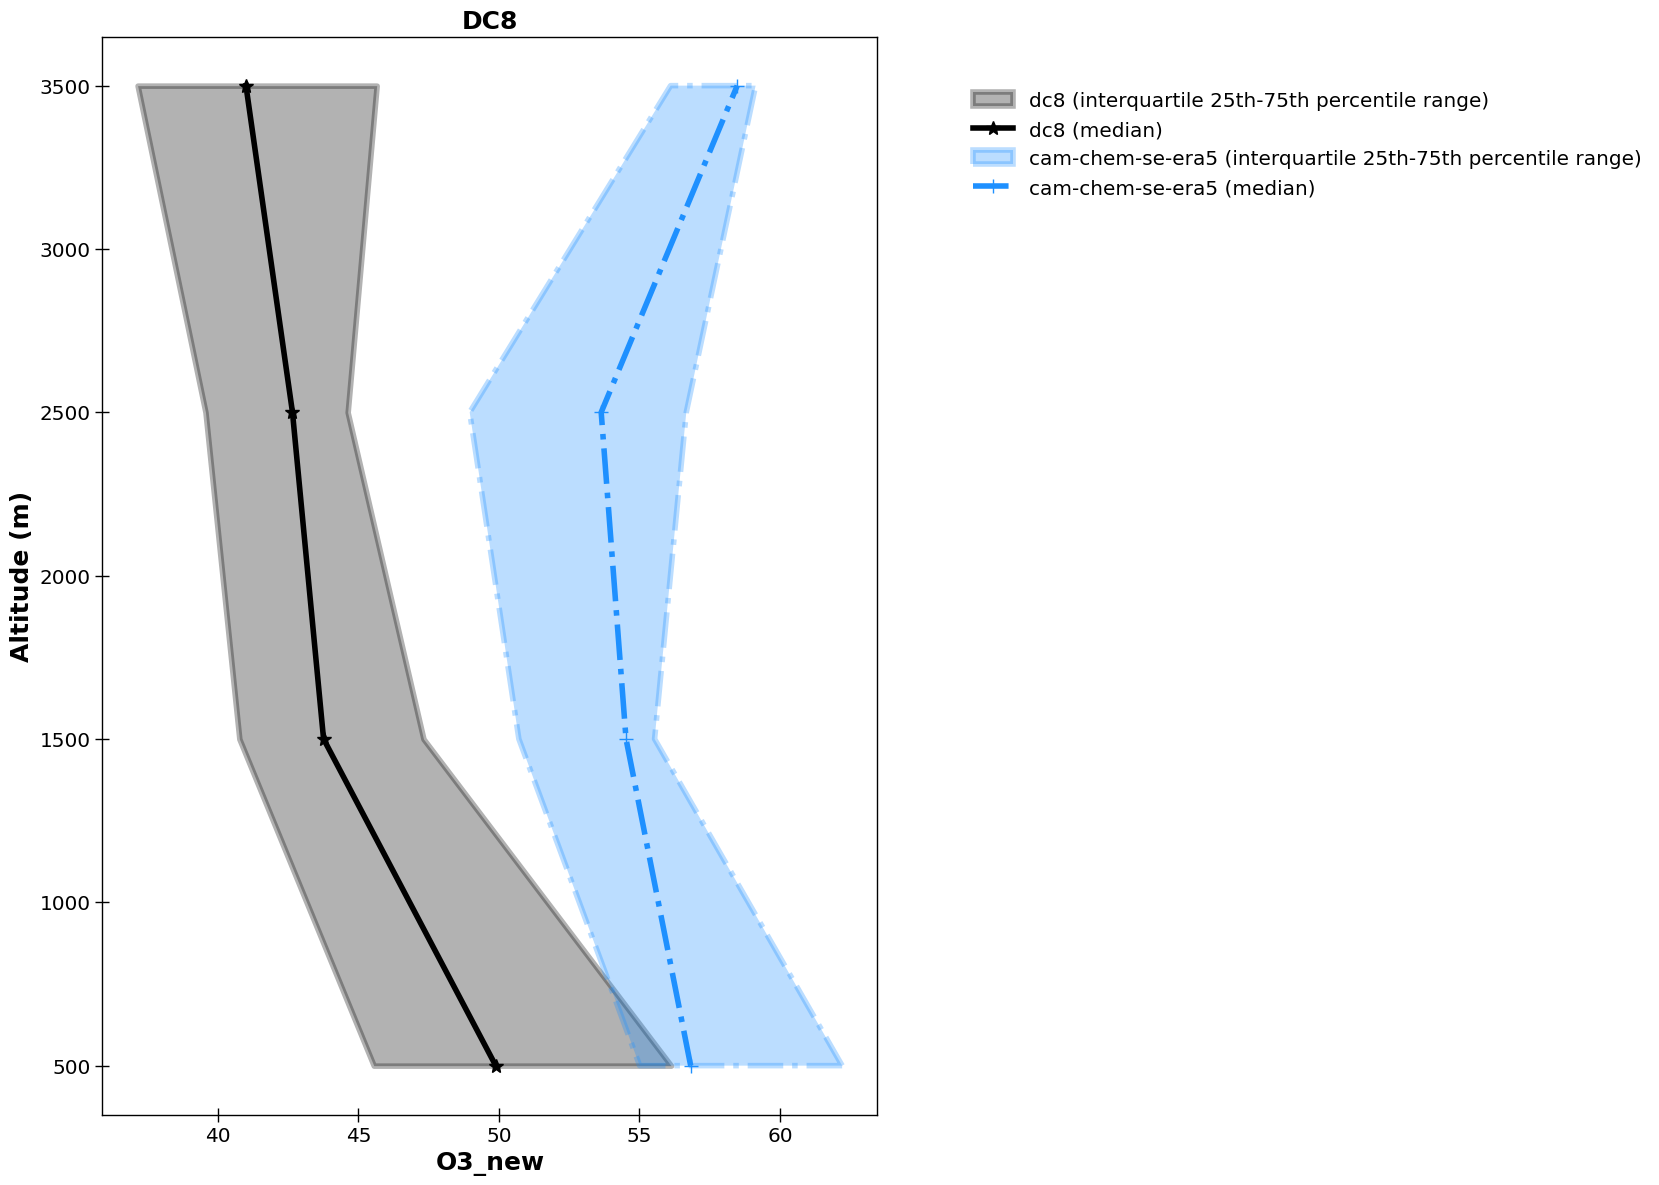

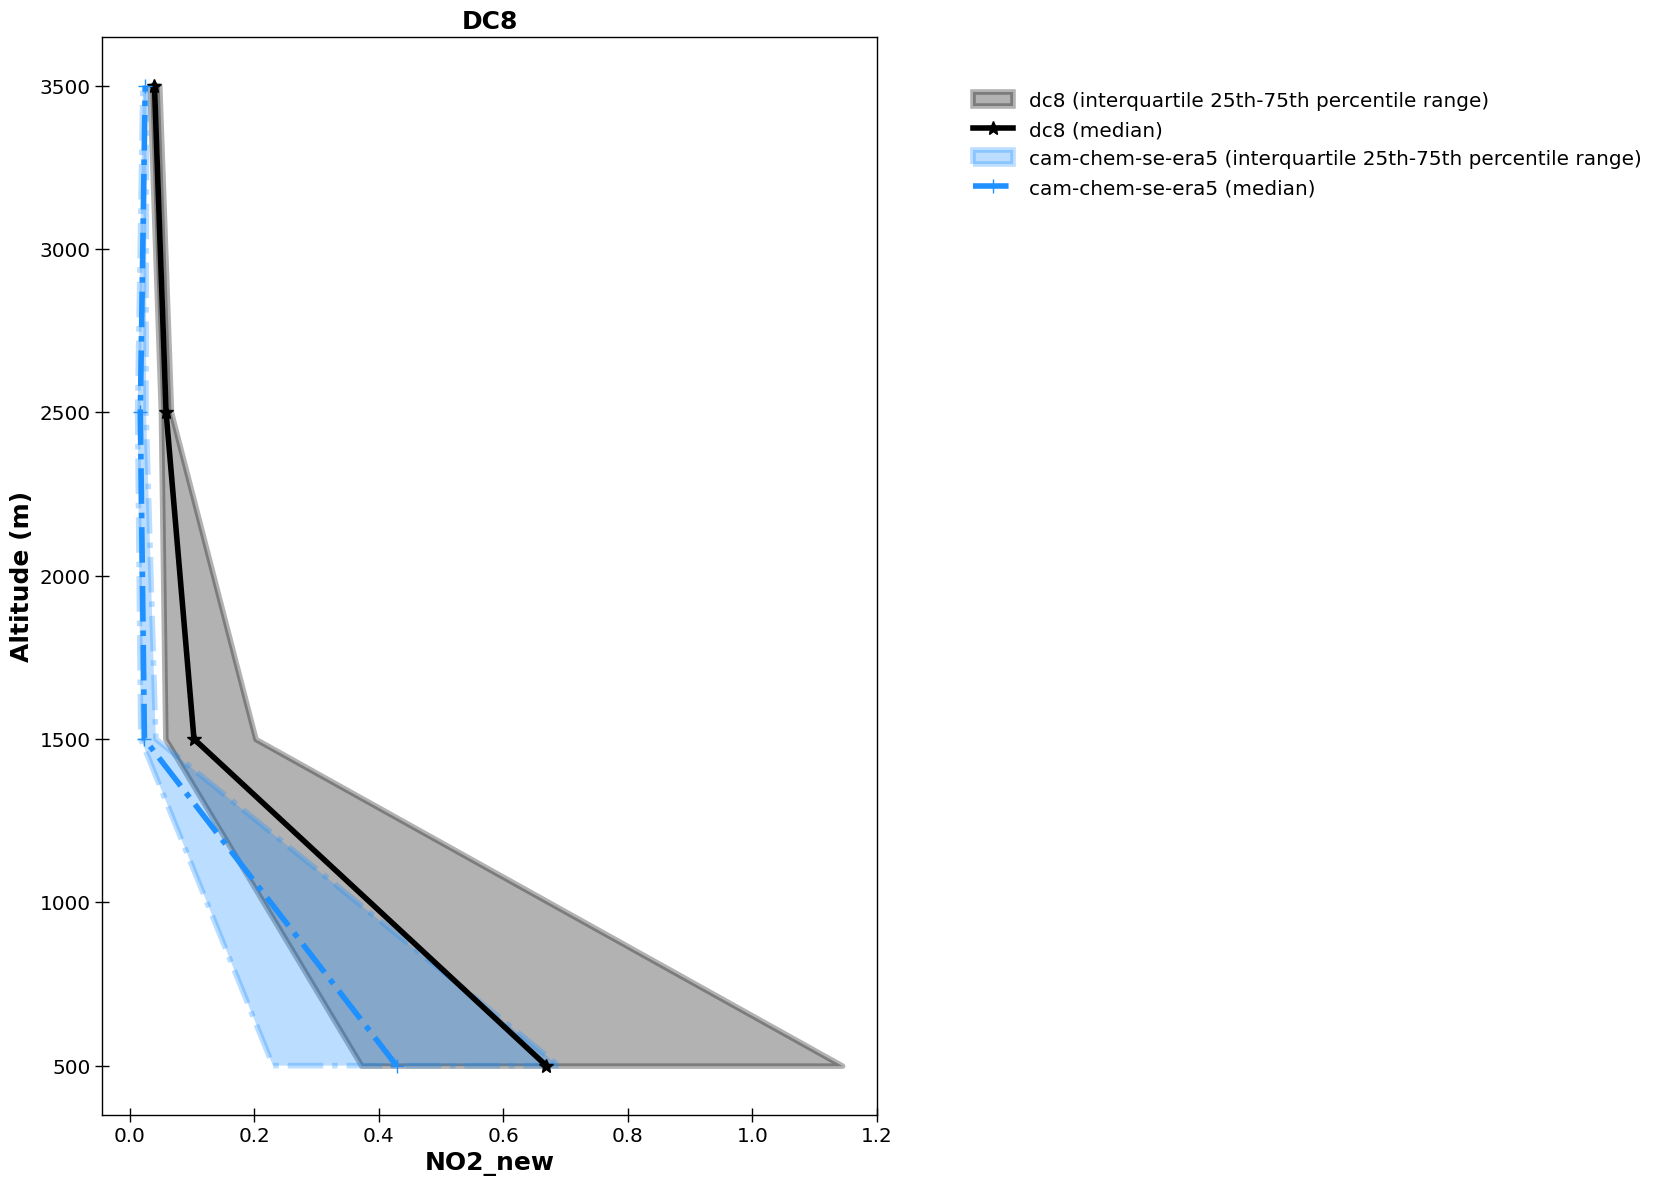

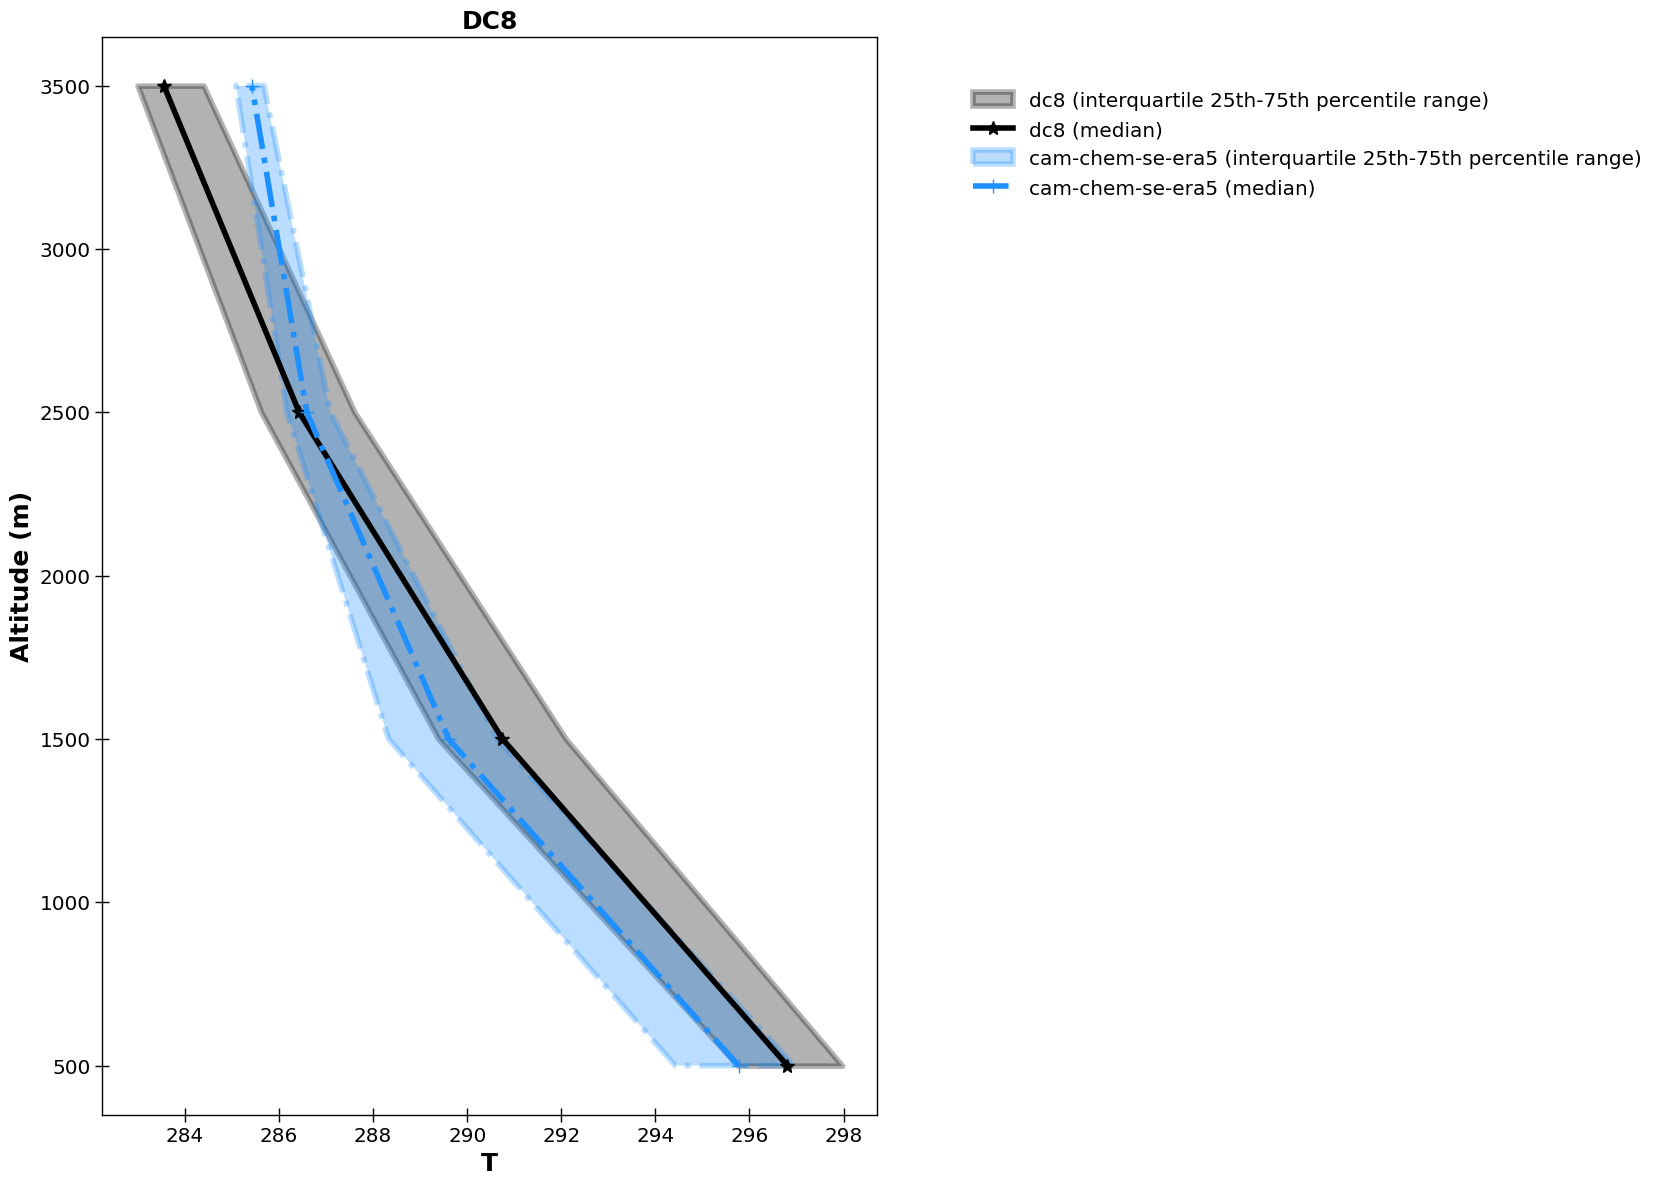

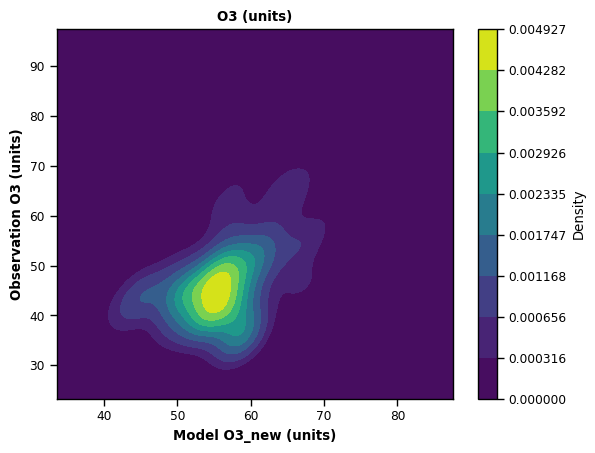

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/1x_asia_aq_cesmse/scatter_dc8.scatter_density.NO2.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
Processing scatter density plot for model 'cam-chem-se-era5' and observation 'dc8'...
Saving scatter density plot to ./output/1x_asia_aq_cesmse/scatter_dc8.scatter_density.NO2.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


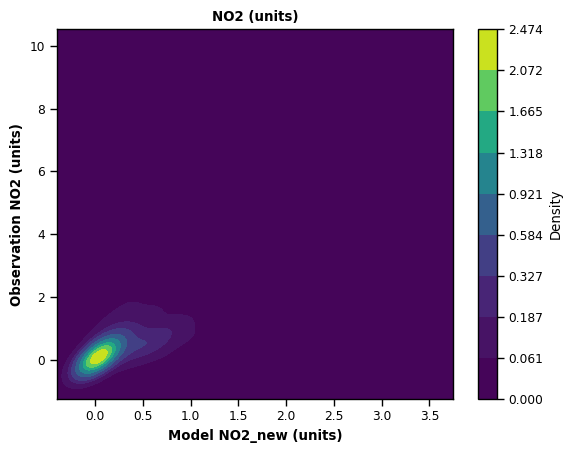

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/1x_asia_aq_cesmse/scatter_dc8.scatter_density.temperature.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
Processing scatter density plot for model 'cam-chem-se-era5' and observation 'dc8'...
Saving scatter density plot to ./output/1x_asia_aq_cesmse/scatter_dc8.scatter_density.temperature.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


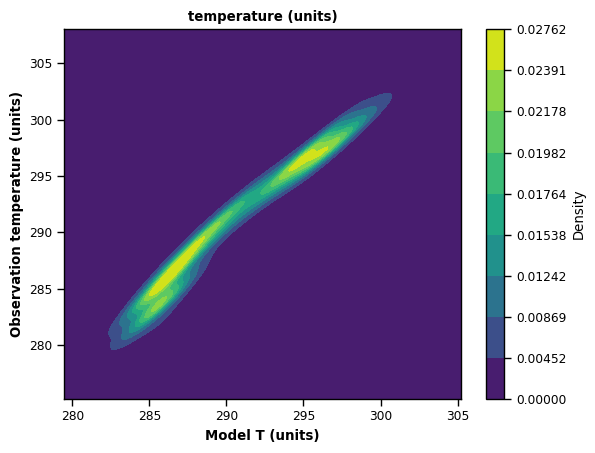

Reference std: 8.938509734178544
Reference std: 1.0007421918034998
Reference std: 5.769215026265254
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_pa.curtain.O3.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
time shape: (496,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (496, 100), ndims: 2
pairdf shape: (496, 12), ndims: 2
cmin and cmax set dynamically based on model and observation data to 28.463416251036836 and 8274.58645703042
Interval value: 10000
Calculated y_ticks: [   364.34707642  10364.34707642  20364.34707642  30364.34707642
  40364.34707642  50364.34707642  60364.34707642  70364.34707642
  80364.34707642  90364.34707642 100364.34707642]
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_pa.curtain.O3.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


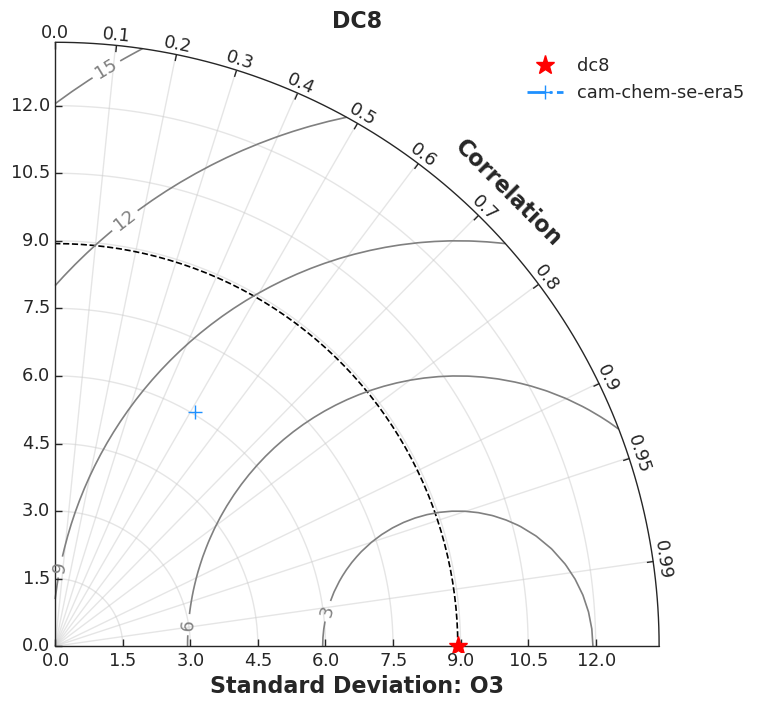

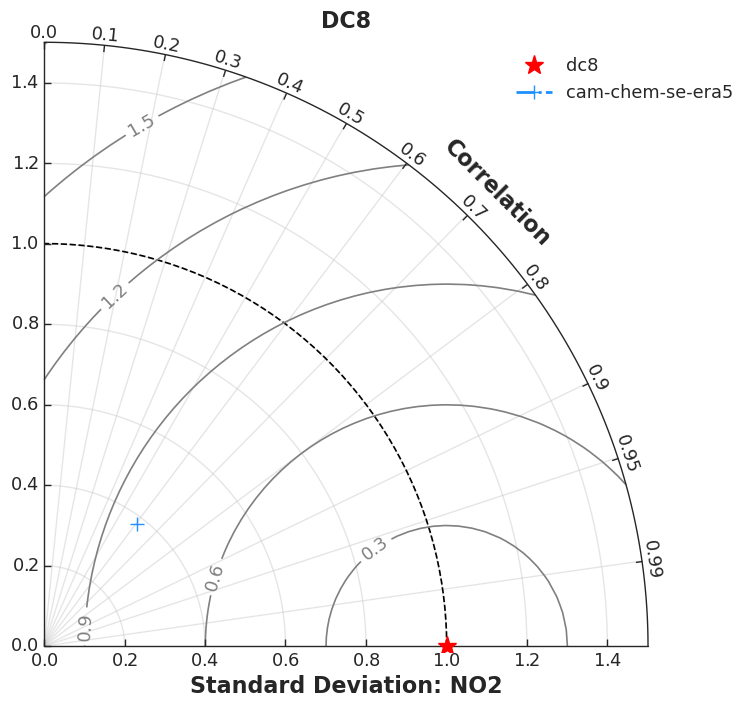

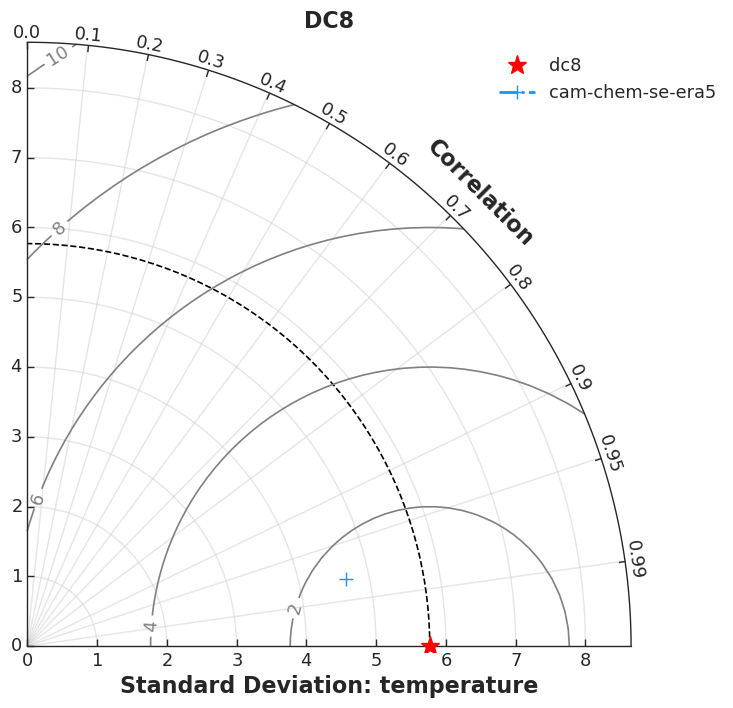

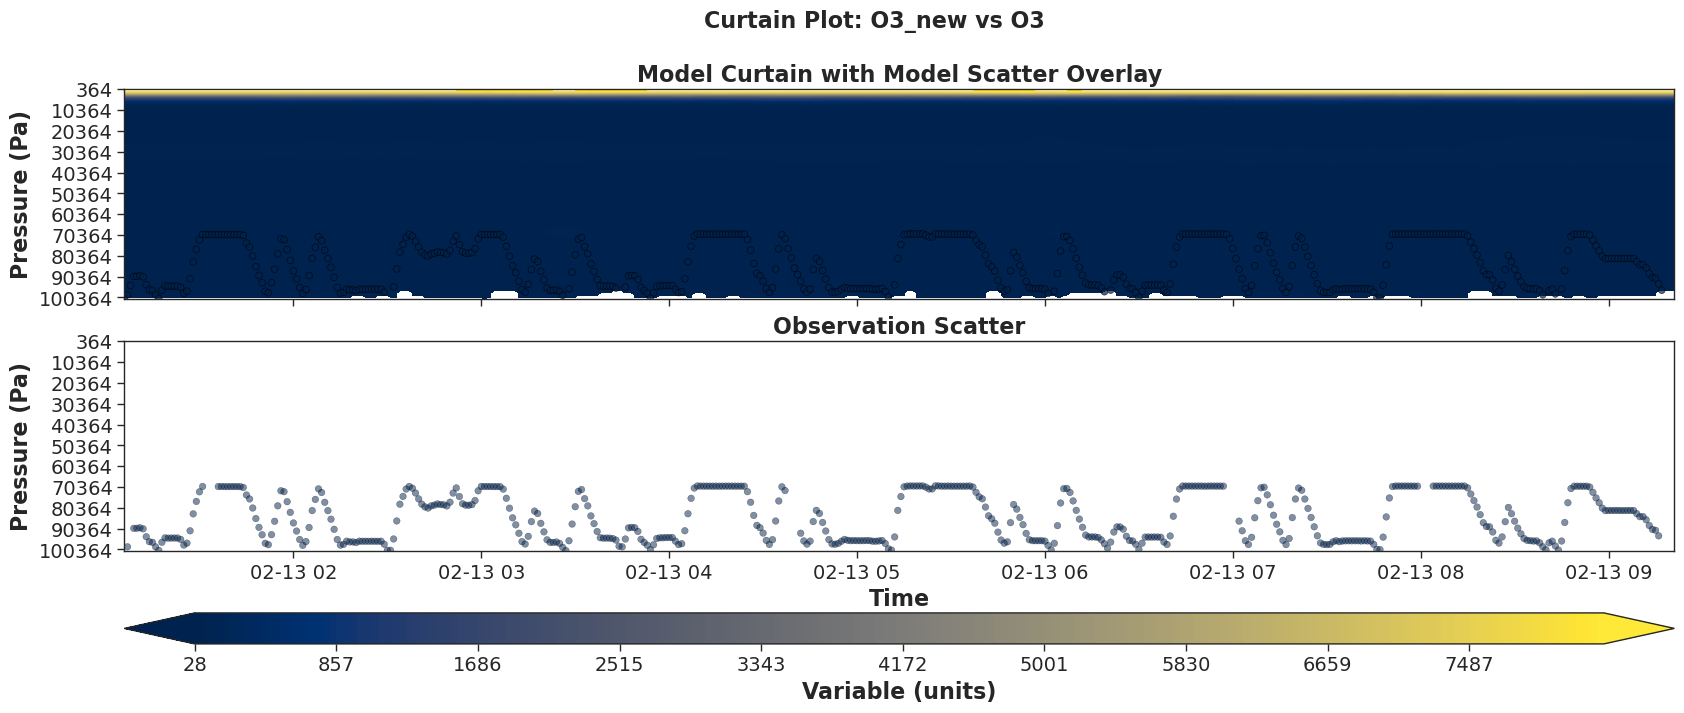

Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_pa.curtain.NO2.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
time shape: (496,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (496, 100), ndims: 2
pairdf shape: (496, 12), ndims: 2
cmin and cmax set dynamically based on model and observation data to -0.1629233333333333 and 11.172213333333334
Interval value: 10000
Calculated y_ticks: [   364.34707642  10364.34707642  20364.34707642  30364.34707642
  40364.34707642  50364.34707642  60364.34707642  70364.34707642
  80364.34707642  90364.34707642 100364.34707642]
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_pa.curtain.NO2.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


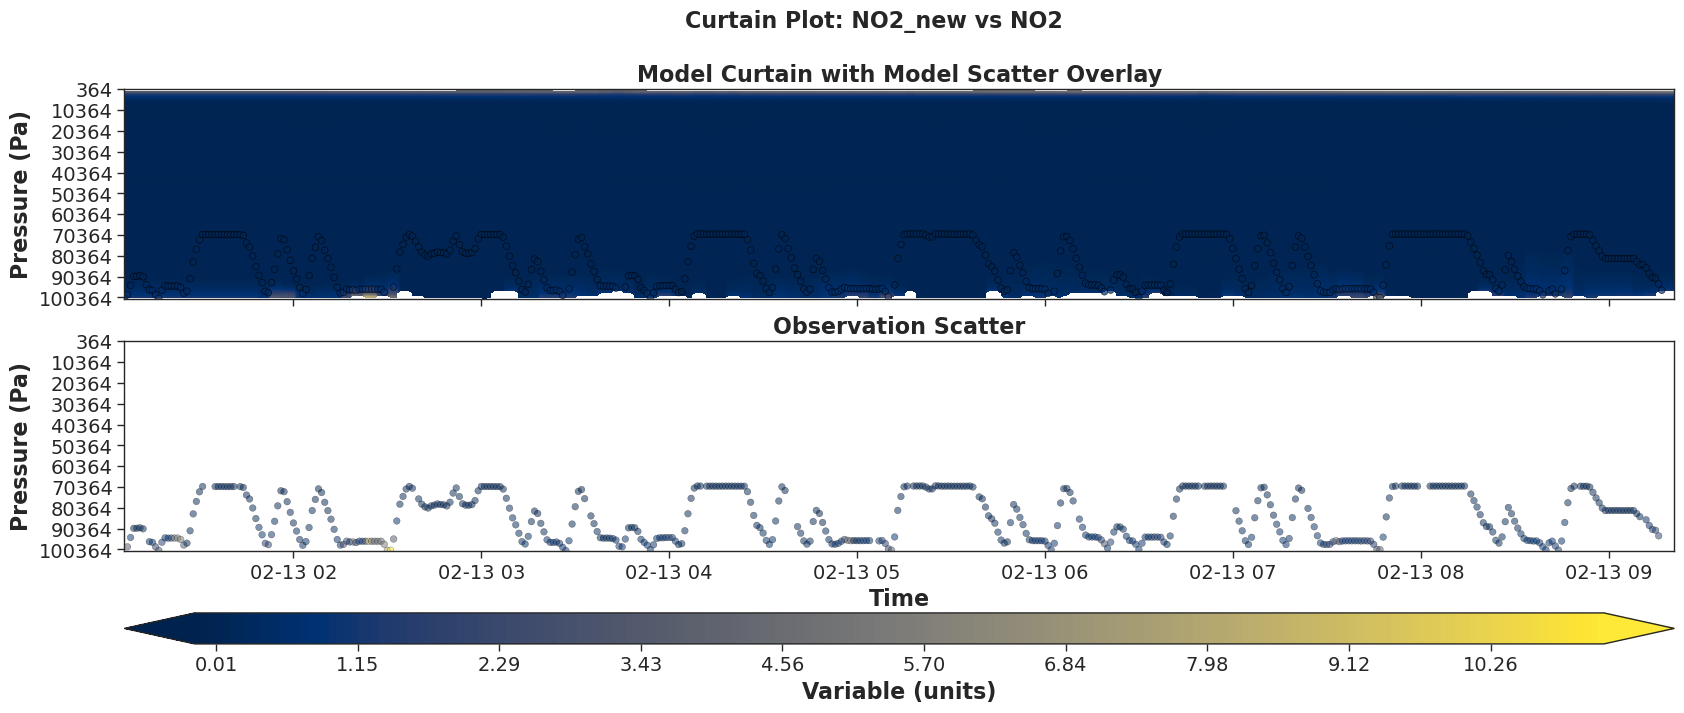

Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_pa.curtain.temperature.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
time shape: (496,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (496, 100), ndims: 2
pairdf shape: (496, 12), ndims: 2
cmin and cmax set dynamically based on model and observation data to 189.85124028562365 and 303.2724
Interval value: 10000
Calculated y_ticks: [   364.34707642  10364.34707642  20364.34707642  30364.34707642
  40364.34707642  50364.34707642  60364.34707642  70364.34707642
  80364.34707642  90364.34707642 100364.34707642]
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_pa.curtain.temperature.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


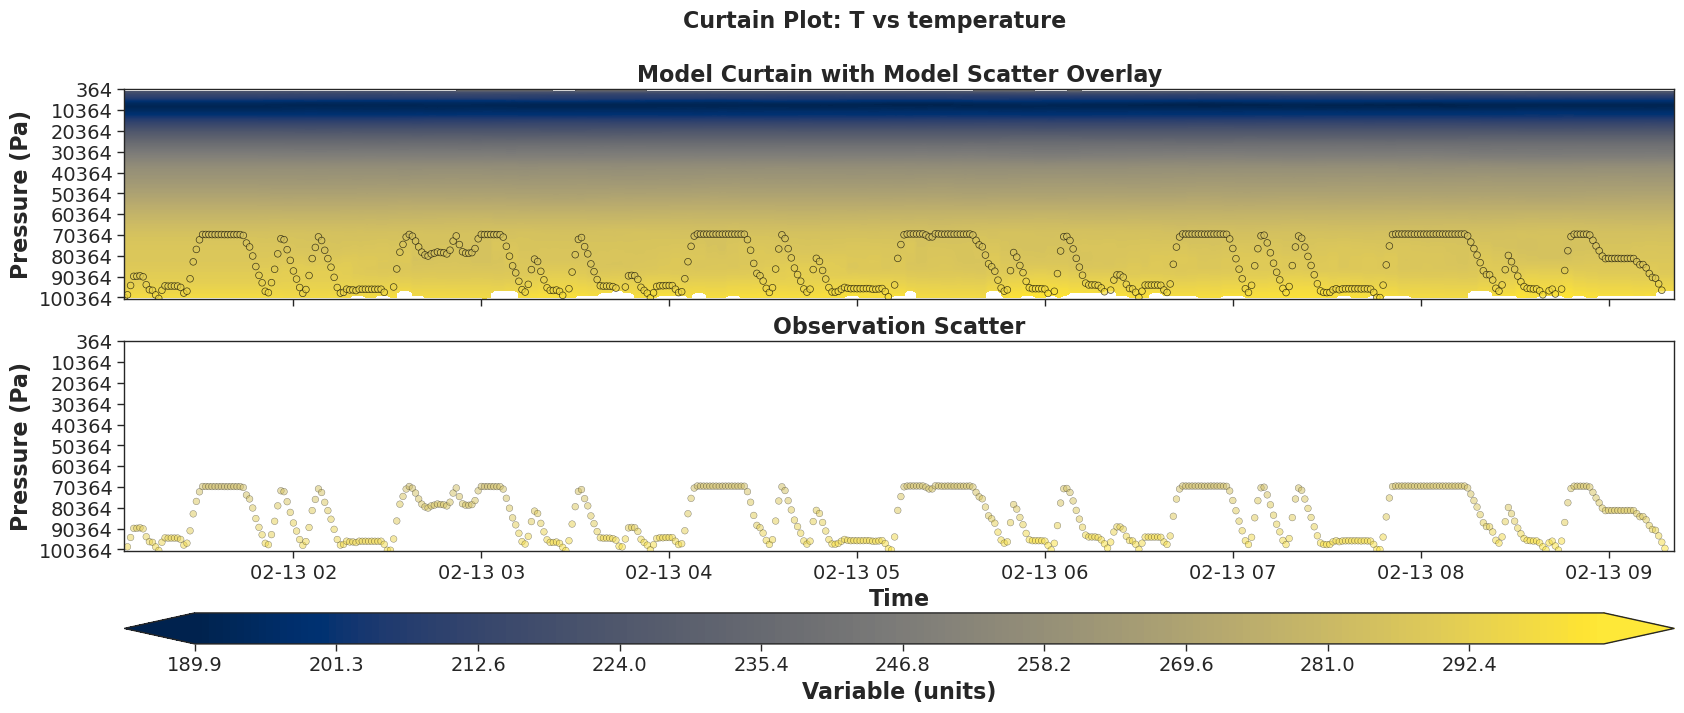

Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_m.curtain.O3.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
time shape: (496,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (496, 100), ndims: 2
pairdf shape: (496, 12), ndims: 2
cmin and cmax set dynamically based on model and observation data to 28.753528371119337 and 8533.525949347237
Interval value: 2000
Calculated y_ticks: [   65.7901089  2065.7901089  4065.7901089  6065.7901089  8065.7901089
 10065.7901089 12065.7901089 14065.7901089 16065.7901089 18065.7901089
 20065.7901089 22065.7901089 24065.7901089 26065.7901089 28065.7901089
 30065.7901089 32065.7901089 34065.7901089 36065.7901089]
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_m.curtain.O3.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


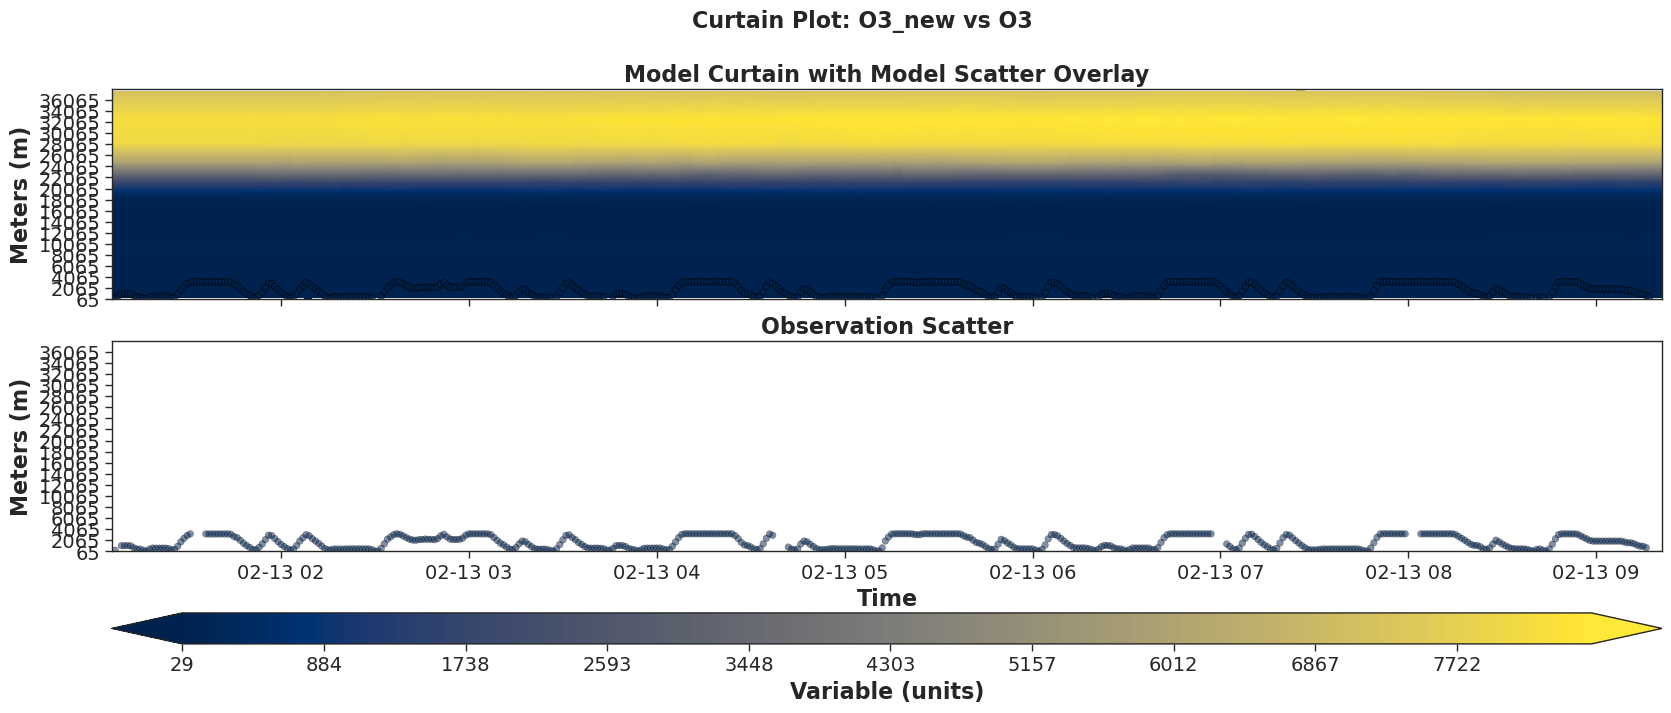

Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_m.curtain.NO2.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
time shape: (496,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (496, 100), ndims: 2
pairdf shape: (496, 12), ndims: 2
cmin and cmax set dynamically based on model and observation data to -0.1629233333333333 and 11.172213333333334
Interval value: 2000
Calculated y_ticks: [   65.7901089  2065.7901089  4065.7901089  6065.7901089  8065.7901089
 10065.7901089 12065.7901089 14065.7901089 16065.7901089 18065.7901089
 20065.7901089 22065.7901089 24065.7901089 26065.7901089 28065.7901089
 30065.7901089 32065.7901089 34065.7901089 36065.7901089]
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_m.curtain.NO2.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


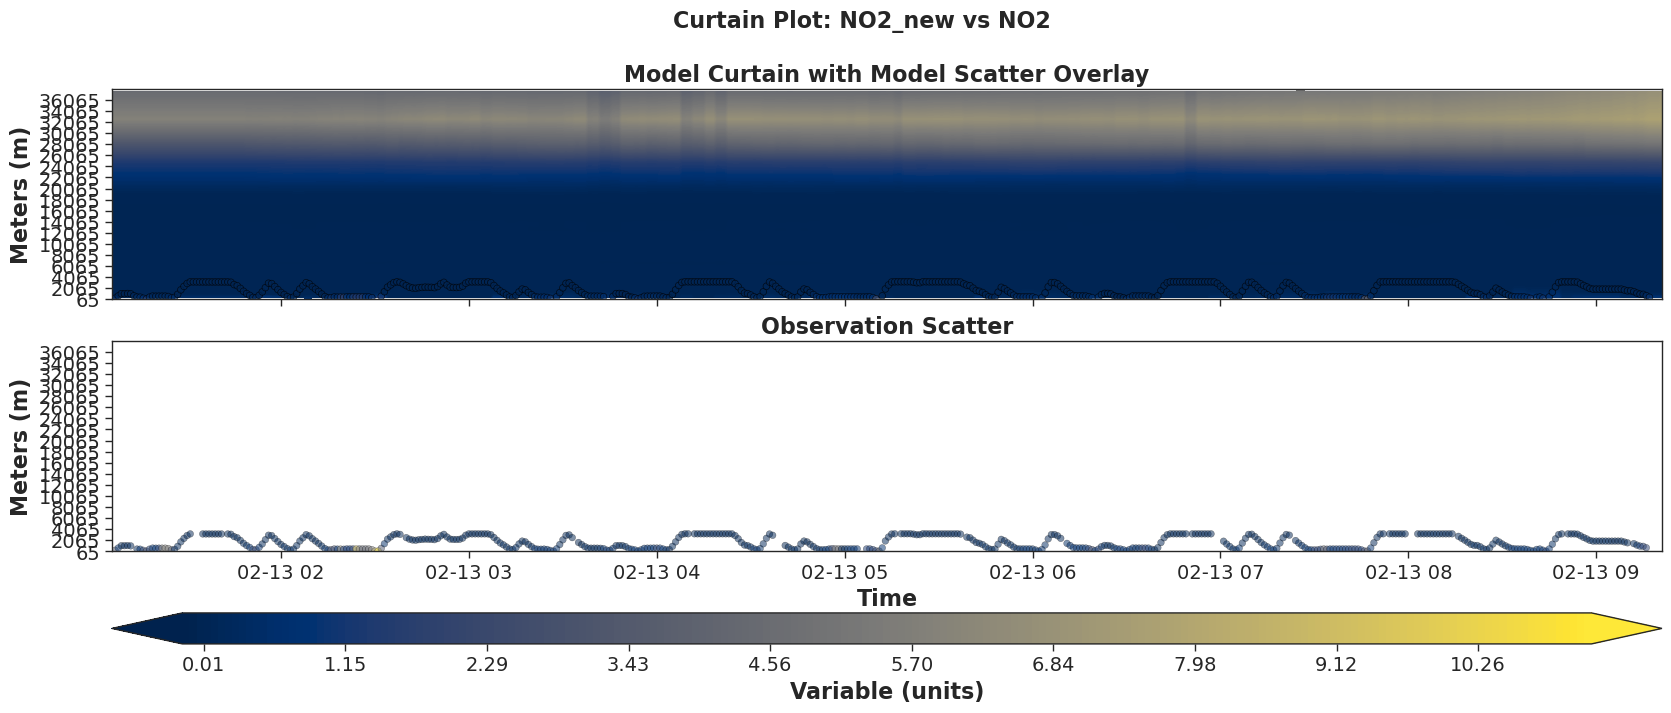

Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_m.curtain.temperature.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...
time shape: (496,), ndims: 1
altitude shape: (100,), ndims: 1
model_data_2d shape: (496, 100), ndims: 2
pairdf shape: (496, 12), ndims: 2
cmin and cmax set dynamically based on model and observation data to 189.8495919668084 and 303.2724
Interval value: 2000
Calculated y_ticks: [   65.7901089  2065.7901089  4065.7901089  6065.7901089  8065.7901089
 10065.7901089 12065.7901089 14065.7901089 16065.7901089 18065.7901089
 20065.7901089 22065.7901089 24065.7901089 26065.7901089 28065.7901089
 30065.7901089 32065.7901089 34065.7901089 36065.7901089]
Saving curtain plot to ./output/1x_asia_aq_cesmse/curtain_dc8_m.curtain.temperature.2024-02-13_00.2024-02-14_23.all.DC8_dc8_vs_cam-chem-se-era5.png...


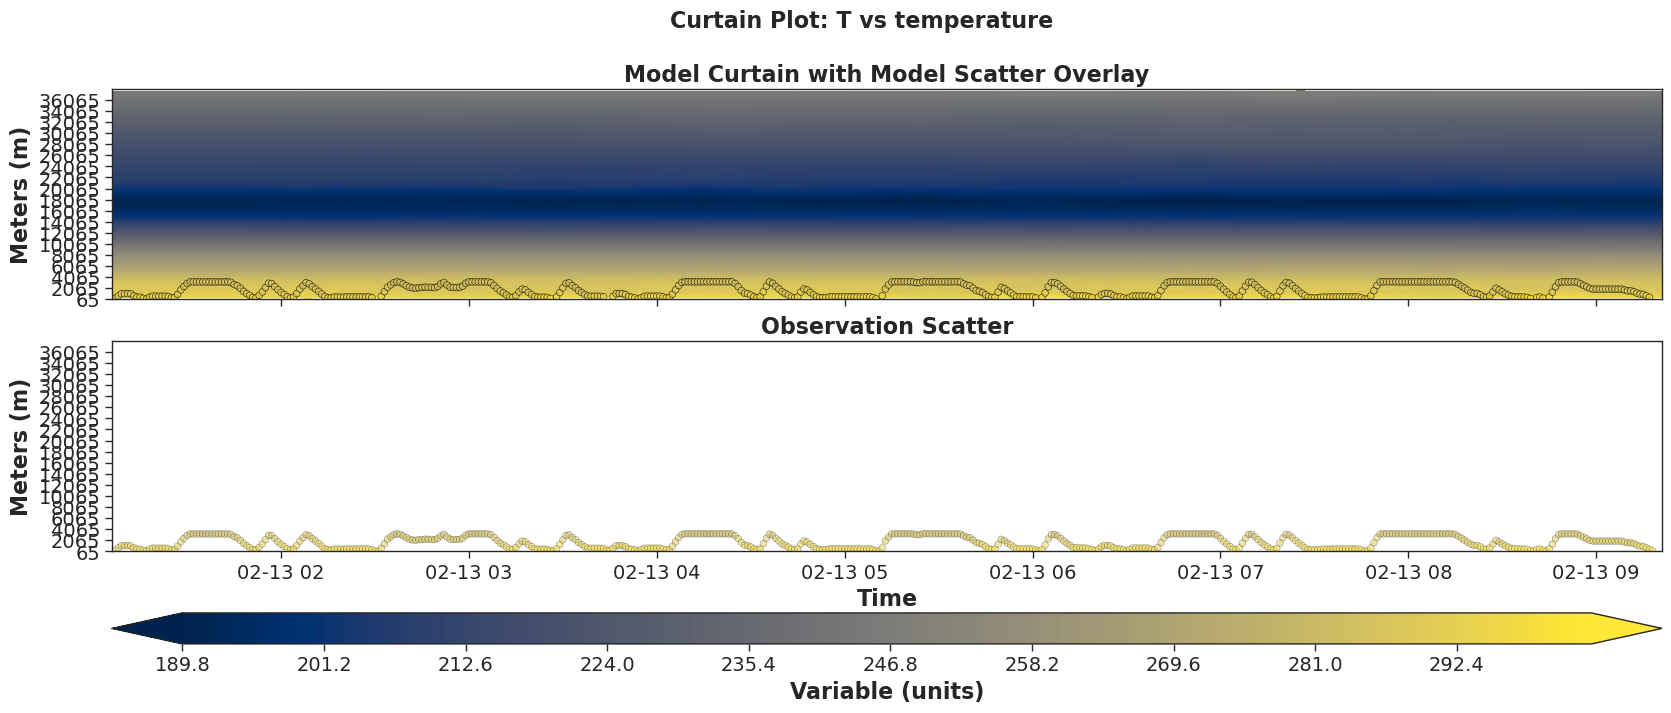

In [8]:
an.plotting()

## Generate stats

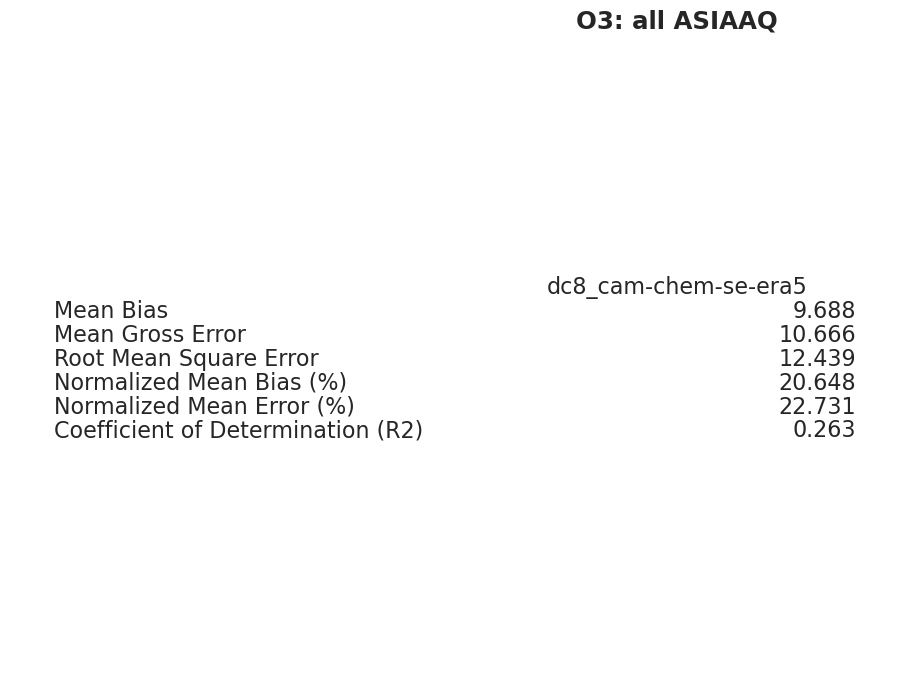

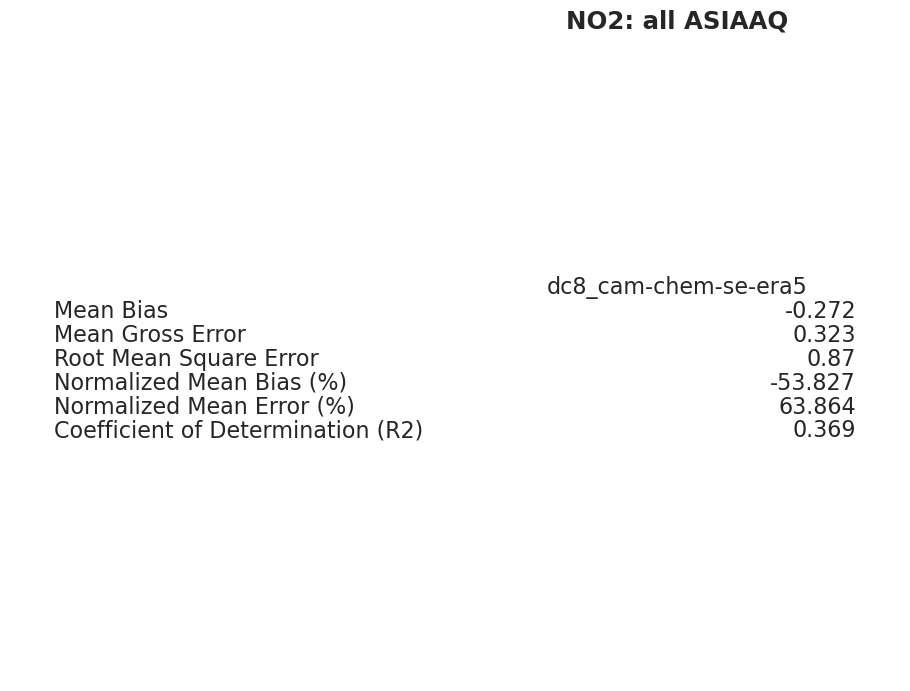

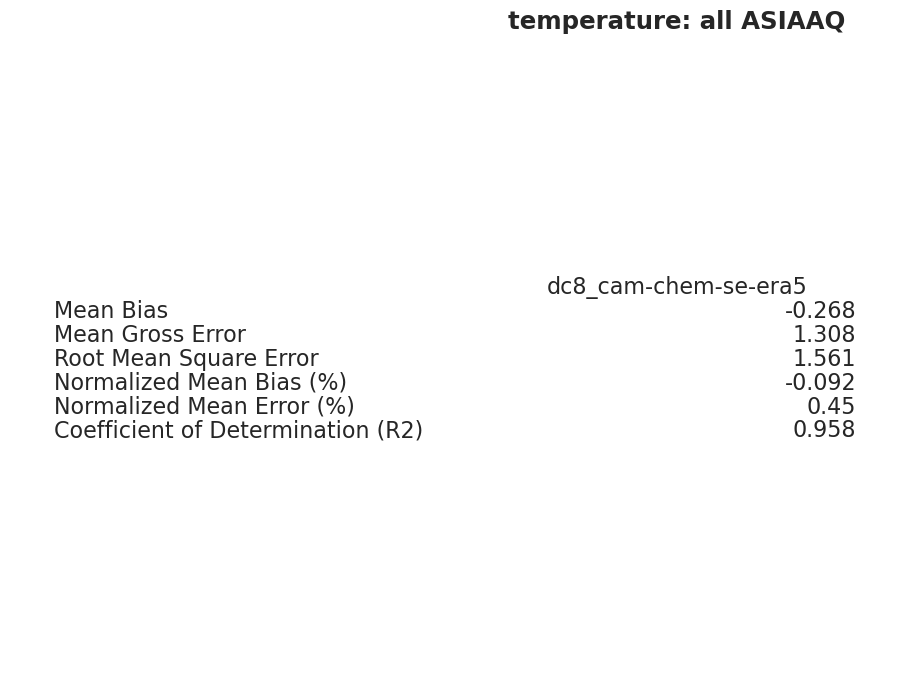

In [9]:
an.stats()